<a href="https://colab.research.google.com/github/RosaCastillo10/P8---LabPDI/blob/main/P8_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introducción**

En esta práctica se aplicaron diferentes técnicas de procesamiento digital de imágenes médicas utilizando filtros espaciales y filtros en el dominio de la frecuencia. Se analizaron los efectos del suavizado, detección de bordes y filtrado frecuencial sobre imágenes médicas en escala de grises.

# **Parte I: Filtros con Máscaras Espaciales Personalizadas**

•	Cargar una radiografia en escala de grises.

•	Aplicar al menos tres filtros de suavizado (media, gaussiano, mediana), usando diferentes tamaños de kernel (3x3, 5x5, 11x11).

•	Aplicar filtros de detección de bordes (Sobel en x, y, Laplaciano, Kirsch) y modificar las máscaras manualmente para observar diferencias.

•	Crear y aplicar una máscara personalizada de realce o detección (hecha por el alumno).

•	Mostrar y comparar los resultados para cada filtro y justificar la elección del tamaño del kernel.


**Librerías**

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

**Carga de Imagen (Parte I)**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Radiografía Original.jpg to Radiografía Original.jpg


**Mostrar Imagen**

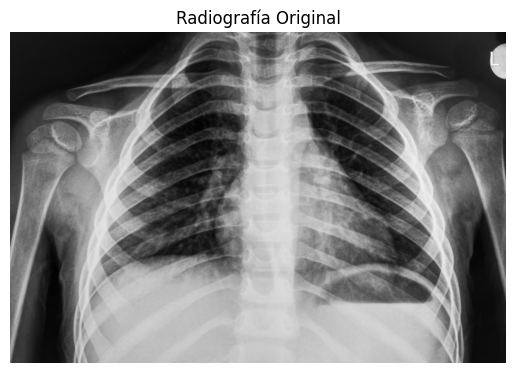

In [ ]:
img1 = cv2.imread('img1.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img1, cmap='gray')
plt.title("Radiografía Original")
plt.axis('off')
plt.show()

**Filtros de suavizado**

In [ ]:
# Media
media_3 = cv2.blur(img1, (3,3))
media_5 = cv2.blur(img1, (5,5))
media_11 = cv2.blur(img1, (11,11))

# Gaussiano
gauss_3 = cv2.GaussianBlur(img1, (3,3), 0)
gauss_5 = cv2.GaussianBlur(img1, (5,5), 0)
gauss_11 = cv2.GaussianBlur(img1, (11,11), 0)

# Mediana
mediana_3 = cv2.medianBlur(img1, 3)
mediana_5 = cv2.medianBlur(img1, 5)
mediana_11 = cv2.medianBlur(img1, 11)

**Resultados de suavizado**

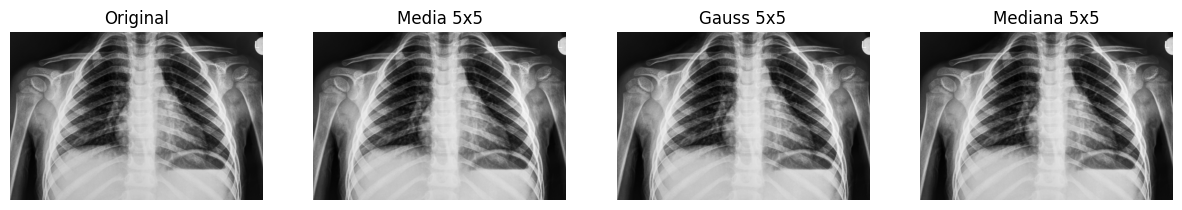

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(img1, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(media_5, cmap='gray')
plt.title("Media 5x5")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(gauss_5, cmap='gray')
plt.title("Gauss 5x5")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(mediana_5, cmap='gray')
plt.title("Mediana 5x5")
plt.axis('off')

plt.show()

**Detección de bordes**

In [ ]:
sobelx = cv2.Sobel(img1, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img1, cv2.CV_64F, 0, 1, ksize=3)

laplaciano = cv2.Laplacian(img1, cv2.CV_64F)

kirsch_kernel = np.array([
    [5, 5, 5],
    [-3, 0, -3],
    [-3, -3, -3]
])

kirsch = cv2.filter2D(img1, -1, kirsch_kernel)

**Máscara personalizada**

In [ ]:
custom_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

realce = cv2.filter2D(img1, -1, custom_kernel)

**Resultados bordes**

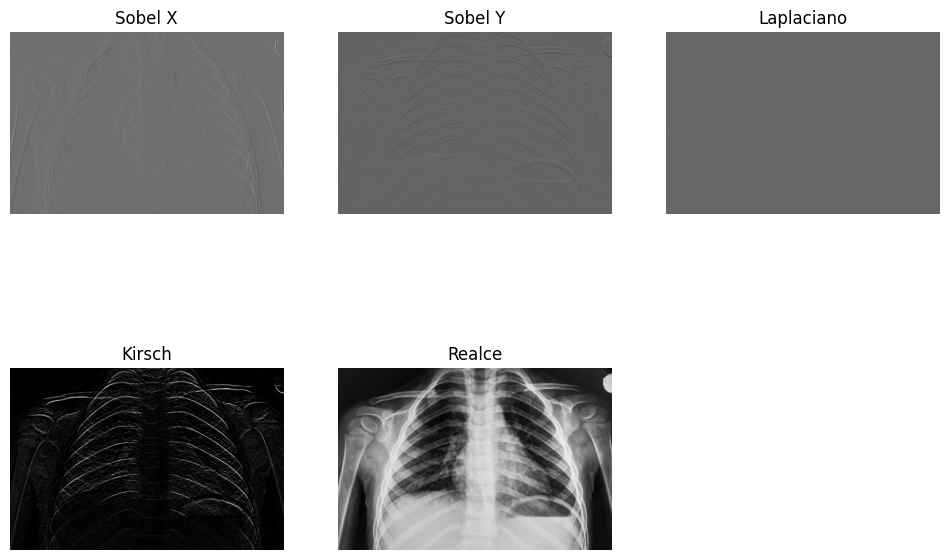

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(sobelx, cmap='gray')
plt.title("Sobel X")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(sobely, cmap='gray')
plt.title("Sobel Y")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(laplaciano, cmap='gray')
plt.title("Laplaciano")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(kirsch, cmap='gray')
plt.title("Kirsch")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(realce, cmap='gray')
plt.title("Realce")
plt.axis('off')

plt.show()

# **Parte II: Filtros en el Dominio de la Frecuencia con Parámetros Modificables**

•	Convertir la imagen médica al dominio de la frecuencia con la Transformada de Fourier.

•	Implementar al menos dos filtros pasa bajas con diferentes radios de corte (ej: 20, 50, 80 píxeles).

•	Implementar al menos dos filtros pasa altas con diferentes configuraciones (círculo, anillo, cruz, etc.).

•	Mostrar cómo afecta cada configuración la nitidez o la pérdida de información en la imagen.

•	Visualizar la máscara aplicada en el dominio de la frecuencia y la imagen transformada inversamente.

•	Aplicarlo a dos imágenes médicas diferentes, e.g., colonoscopía, endoscopía, cortes histológicos, etc.

**Carga de Imágenes (Parte II)**

In [ ]:
uploaded = files.upload()

img2 = cv2.imread('colonoscopia.jpg', cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread('endoscopia.jpg', cv2.IMREAD_GRAYSCALE)

Saving colonoscopia.jpg to colonoscopia.jpg
Saving endoscopia.jpg to endoscopia.jpg


**Función Fourier**

In [ ]:
def fourier(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    mag = 20 * np.log(np.abs(fshift) + 1)
    return fshift, mag

**Función Fourier (Imagen 2)**

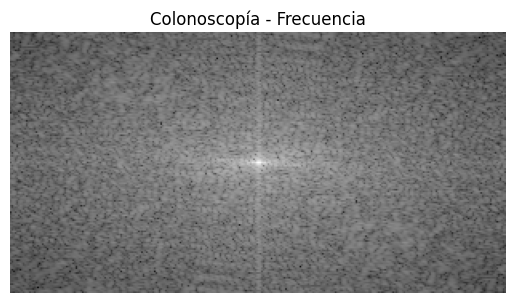

In [ ]:
f2, mag2 = fourier(img2)

plt.imshow(mag2, cmap='gray')
plt.title("Colonoscopía - Frecuencia")
plt.axis('off')
plt.show()

**Función Fourier (Imagen 3)**

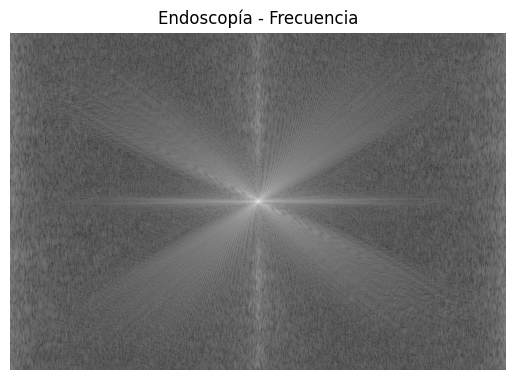

In [ ]:
f3, mag3 = fourier(img3)

plt.imshow(mag3, cmap='gray')
plt.title("Endoscopía - Frecuencia")
plt.axis('off')
plt.show()

**Filtro pasa bajas**

In [ ]:
def low_pass(shape, r):
    rows, cols = shape
    crow, ccol = rows//2, cols//2

    mask = np.zeros((rows, cols), np.uint8)

    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i-crow)**2 + (j-ccol)**2) <= r:
                mask[i,j] = 1

    return mask

**Aplicar pasa bajas (Imagen 2)**

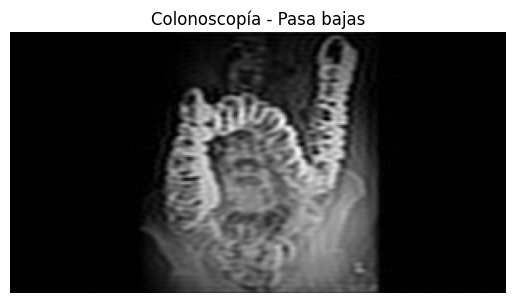

In [ ]:
mask = low_pass(img2.shape, 50)

filt = f2 * mask
img_back = np.fft.ifft2(np.fft.ifftshift(filt))
img_back = np.abs(img_back)

plt.imshow(img_back, cmap='gray')
plt.title("Colonoscopía - Pasa bajas")
plt.axis('off')
plt.show()

**Filtro pasa altas**

In [ ]:
def high_pass(shape, r):
    rows, cols = shape
    crow, ccol = rows//2, cols//2

    mask = np.ones((rows, cols), np.uint8)

    for i in range(rows):
        for j in range(cols):
            if np.sqrt((i-crow)**2 + (j-ccol)**2) <= r:
                mask[i,j] = 0

    return mask

**Aplicar pasa altas (Imagen 3)**

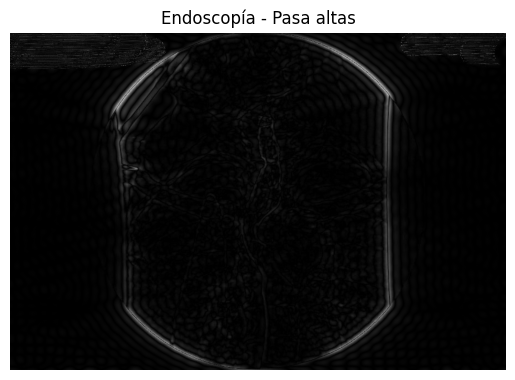

In [ ]:
mask_h = high_pass(img3.shape, 30)

filt_h = f3 * mask_h
img_high = np.fft.ifft2(np.fft.ifftshift(filt_h))
img_high = np.abs(img_high)

plt.imshow(img_high, cmap='gray')
plt.title("Endoscopía - Pasa altas")
plt.axis('off')
plt.show()

# **Conclusión**

En este trabajo se aplicaron técnicas de procesamiento digital de imágenes médicas utilizando filtros en el dominio espacial y en el dominio de la frecuencia. En la Parte I, los filtros de suavizado (media, gaussiano y mediana) permitieron reducir el ruido en la radiografía, observándose que el tamaño del kernel influye directamente en el nivel de suavizado y en la pérdida de detalles: kernels pequeños conservan más información, mientras que kernels grandes eliminan mayor ruido pero también reducen la nitidez de estructuras importantes.

Por otro lado, los filtros de detección de bordes (Sobel, Laplaciano y Kirsch) mostraron su utilidad para resaltar contornos y estructuras internas de la imagen, siendo el filtro Laplaciano más sensible a cambios bruscos de intensidad. La máscara personalizada permitió mejorar el contraste y la nitidez, demostrando cómo el diseño manual de kernels puede adaptarse a objetivos específicos.

En la Parte II, la Transformada de Fourier permitió analizar la distribución de frecuencias en imágenes médicas como colonoscopía y endoscopía. Los filtros pasa bajas suavizaron las imágenes eliminando detalles finos, mientras que los filtros pasa altas resaltaron bordes y estructuras, aunque con pérdida de información general. Se concluye que el dominio de la frecuencia es una herramienta clave para la mejora y análisis de imágenes médicas, ya que permite manipular información visual de forma más controlada según la aplicación clínica o de diagnóstico.

# **Referencias bibliográficas**

*   Gonzalez, R. C., & Woods, R. E.

*   (2018). Digital image processing (4th ed.). Pearson.

*   OpenCV. (2026). OpenCV documentation. https://docs.opencv.org/

*   https://github.com/dilp90/PDI/tree/main/DominioDelEspacio

*   https://github.com/dilp90/PDI/blob/main/DominioDelEspacio/PDI_8_FiltrosConMascaras.ipynb

*   https://github.com/dilp90/PDI/blob/main/DominioDeLaFrecuencia/TransformadaFourier_FiltroPasaBajas_y_PasaAlta.ipynb